# 18장 실습 — 한계 수익 분석과 잔여 과제

마지막 노트북은 셋을 한다.

1. **한계 수익을 한 표로 모은다.** 16장이 다시 검정한 주장 스물하나를 부별로 늘어놓고, 효과의 크기와 시드 단위 유의성을 한 그림에 그린다
2. **고리를 한 바퀴 닫는다.** 그림 0.1의 되먹임 곡선 — 현장 로그가 1부로 돌아온다 — 을 실제로 한 번 돌린다. 행동 복제가 무너지는 새 현장에 내보내고, 모니터가 경보를 울린 판에서 사람(참 위치를 보는 대본 제어기가 대역을 맡는다)이 개입한 기록을 모아 데이터에 더하고, 다시 학습한다
3. **저장소를 확인한다.** 열여덟 장이 남긴 파일을 폴더별로 센다

끝에서 `report/margins.json` 과 `policy/bc_v2.pt` 를 남긴다. 

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
import copy

SIG = .22


def dart_eps(count, seed, n=32, cond=None, sig=SIG):
    """잡음 주입 시연을 판 단위로 모은다 (cond: 그 조건의 셀)"""
    rng = np.random.default_rng(seed)
    env = Pert(n, seed, **COND[cond]) if cond else Cell(n, seed)
    cur = [[] for _ in range(n)]
    out = []
    while len(out) < count:
        o = env.obs()
        lab = servo(env)
        act = np.clip(lab + rng.normal(0, sig, lab.shape), -1, 1)
        for i in range(n):
            cur[i].append((o[i], lab[i]))
        dn = env.step(act.astype(np.float32))[1]
        for i in np.flatnonzero(dn):
            out.append(cur[i])
            cur[i] = []
    out = out[:count]
    X = np.array([a for e in out for a, _ in e], np.float32)
    Y = np.array([b for e in out for _, b in e], np.float32)
    return X, Y, np.array([len(e) for e in out])


def load_cell(path="data/cell_v1"):
    """6장의 데이터셋을 읽는다 — 없으면 같은 설정으로 모은다"""
    f = f"{path}/data/chunk-000/file-000.parquet"
    if os.path.exists(f):
        import pyarrow.parquet as pq
        t = pq.read_table(f)
        flat = lambda c: np.asarray(t[c].combine_chunks().flatten())
        X = flat("observation.state").reshape(-1, 10)
        X = X.astype(np.float32)
        Y = flat("action").reshape(-1, 2).astype(np.float32)
        st = json.load(open(f"{path}/meta/stats.json"))
        st = st["observation.state"]
        print(f"{path} 를 읽었다 — {len(X):,} 스텝")
        return X, Y, st
    X, Y, _ = dart_eps(128, seed=1)
    z = X[:, :8] / 10.
    st = {"method": "평균·표준편차", "mean": z.mean(0).tolist(),
          "std": (z.std(0) + 1e-8).tolist()}
    print(f"{path} 가 없다 — 잡음 주입 시연 128판을 모았다")
    return X, Y, st


XS, YS, STATS = load_cell()
MU = np.array(STATS["mean"], np.float32) * 10.   # 셀 척도로
SD = np.array(STATS["std"], np.float32) * 10.


def nz(o):
    """4장의 정규화 — 위치·속도 여덟 차원만 평균·표준편차로"""
    o = o.copy()
    o[:, :8] = (o[:, :8] - MU) / SD
    return o.astype(np.float32)


def pol(net):
    """정규화한 관측으로 평균 행동을 낸다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(nz(env.obs()))).numpy()
    return f


def cycle(rows):
    """성공한 판의 주기 중앙값 (스텝)"""
    st = [r[6] for r in rows if r[4]]
    return float(np.median(st)) if st else float("nan")

data/cell_v1 를 읽었다 — 5,792 스텝


## 한계 수익을 한 표로

16장의 `report/audit.json` 을 읽는다. 없으면 16장과 같은 방법으로 로그에서 다시 계산한다. 비용은 장마다 종류가 달라 수로 합칠 수 없으므로, 종류만 붙인다.

In [8]:
from scipy import stats

COST = dict(c.split("|") for c in """
2장 실행 잡음|수집 코드
3장 시연 8→64 (명목)|시연
3장 시연 8→64 (배포)|시연
4장 정규화|설계
4장 상대 좌표|설계
5장 큐레이션|시연 버림
6장 6비트|없음
7장 복제 대 강화학습|방법
7장 이어 학습|상호작용
8장 학습률 (배포)|계산
8장 학습률 (지연 2)|계산
8장 시연 두 배 (지연 2)|시연
9장 더해 쓰기|현장 시연
11장 식별 (대역)|현장 기록
11장 식별 (다른 현장)|현장 기록
13장 해상도 160|인식 정확도
14장 양자화|인식 정확도
14장 청킹 (fp32)|없음
14장 청킹 (int8 위)|없음
15장 세 층 (지연 2)|개입
15장 세 층 (편향 ×2)|개입
""".strip().splitlines())


def part_of(name):
    ch = int(name.split("장")[0])
    return (ch - 1) // 3 + 1


if os.path.exists("report/audit.json"):
    AUD = json.load(open("report/audit.json"))["claims"]
    print("report/audit.json 을 읽었다")
else:
    AUD = []
    print("report/audit.json 이 없다 — 16장을 먼저 실행한다")

print()
print(pad("부", 4) + pad("주장", 26) + pad("Δ", 8, True)
      + pad("시드 p", 8, True) + pad("판 p", 10, True)
      + pad("비용", 12, True))
for a in AUD:
    ps = "—" if a["p_sd"] != a["p_sd"] else f"{a['p_sd']:.3f}"
    print(pad(part_of(a["name"]), 4) + pad(a["name"], 26)
          + pad(f"{a['delta']:+.3f}", 8, True) + pad(ps, 8, True)
          + pad(f"{a['p_ep']:.1e}", 10, True)
          + pad(COST.get(a["name"], ""), 12, True))

report/audit.json 을 읽었다

부  주장                             Δ  시드 p      판 p        비용
1   2장 실행 잡음               +0.123   0.020   9.2e-33   수집 코드
1   3장 시연 8→64 (명목)        +0.143   0.091   1.0e-41        시연
1   3장 시연 8→64 (배포)        -0.001   0.995   9.4e-01        시연
2   4장 정규화                  +0.550   0.045  3.0e-165        설계
2   4장 상대 좌표               +0.145   0.106   4.4e-30        설계
2   5장 큐레이션                +0.154   0.068   3.0e-25   시연 버림
2   6장 6비트                   -0.001   0.964   1.0e+00        없음
3   7장 복제 대 강화학습        +0.439   0.026  1.5e-265        방법
3   7장 이어 학습               -0.144   0.239   2.6e-49    상호작용
3   8장 학습률 (배포)           +0.034   0.408   5.3e-12        계산
3   8장 학습률 (지연 2)         +0.127   0.267   8.2e-09        계산
3   8장 시연 두 배 (지연 2)     +0.189   0.124   3.3e-21        시연
3   9장 더해 쓰기               +0.063   0.121   5.5e-22   현장 시연
4   11장 식별 (대역)            +0.064   0.119   1.4e-24   현장 기록
4   11장 식별 (다른 현장)       +0.083   0.301   4.3e-03   현장 기록
5 

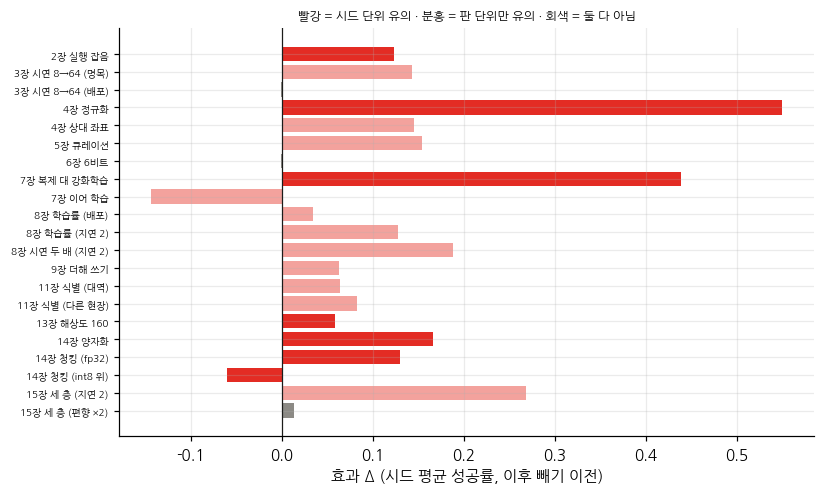

In [9]:
if AUD:
    fig, ax = plt.subplots(figsize=(7.6, 4.6))
    ys = np.arange(len(AUD))[::-1]
    for y, a in zip(ys, AUD):
        sig = a["p_sd"] == a["p_sd"] and a["p_sd"] < .05
        col = RED if sig else (PINK if a["p_ep"] < .05 else GREY)
        ax.barh(y, a["delta"], color=col)
    ax.set_yticks(ys, [a["name"] for a in AUD], fontsize=6.5)
    ax.axvline(0, color=INK, lw=.8)
    ax.set_xlabel("효과 Δ (시드 평균 성공률, 이후 빼기 이전)")
    ax.set_title("빨강 = 시드 단위 유의 · 분홍 = 판 단위만 유의"
                 " · 회색 = 둘 다 아님", fontsize=8)
    plt.tight_layout()
    plt.show()

## 고리를 한 바퀴 닫는다

**새 현장**은 관측 편향이 배포 조건의 세 배인 곳이다(12장에서 행동 복제가 0.151로 무너진 조건). 지연 1주기, 마찰 0.8은 배포 조건과 같다.

내보낸 정책을 모니터가 지켜본다(15장의 불일치, 요청 세 번 연속). 경보가 울리면 그 판의 끝까지 **사람**이 조작한다. 사람의 대역은 1장의 대본 제어기다 — 사람은 카메라가 아니라 실제 장면을 보므로 **참 위치**를 읽는다. 사람이 조작한 스텝마다 (정책이 본 관측, 사람의 명령) 쌍을 기록한다. 이것이 현장 로그다.

In [10]:
XN = nz(XS)
BC = (torch.load("policy/bc_v1.pt", weights_only=False)
      if os.path.exists("policy/bc_v1.pt") else bc(XN, YS, seed=0))
WATCH = [BC] + [bc(XN, YS, seed=s) for s in (1, 2)]
env, D0 = Cell(100, 7), []
for t in range(EP * 2):
    o = torch.from_numpy(nz(env.obs()))
    with torch.no_grad():
        A = np.stack([m.pi(o).numpy() for m in WATCH])
    D0.append(A.std(0).max(1))
    env.step(A[0])
TAU = float(np.quantile(np.concatenate(D0), .999))
COND["새 현장"] = dict(bias=(.018, -.012), lat=1, mu=.8)
COND["편향 ×2"] = dict(bias=(.012, -.008), lat=1, mu=.8)
print(f"모니터 문턱 τ = {TAU:.3f}  (명목 99.9% 분위)")


def deploy(nets, cond, n=100, reps=2, seed=500, tag=0, ver="fly"):
    """경보가 울리면 사람이 끝까지 조작한다. 개입 기록을 모은다"""
    env = Pert(n, seed, **COND[cond])
    cnt, alert = np.zeros(n), np.zeros(n, bool)
    rows, X, Y, flags = [], [], [], []
    for t in range(EP * reps):
        o = env.obs()
        x = torch.from_numpy(nz(o))
        with torch.no_grad():
            A = np.stack([m.pi(x).numpy() for m in nets])
        cnt = np.where(A.std(0).max(1) > TAU, cnt + 1, 0)
        alert |= cnt >= 3
        a = A[0].copy()
        if alert.any():
            h = servo(env)                 # 사람 — 참 위치를 본다
            a[alert] = h[alert]
            X.append(o[alert])
            Y.append(h[alert])
        _, dn, sc = env.step(a)
        for i, s_i in zip(np.flatnonzero(dn), sc):
            hit, wrong, steps, k = s_i
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
            flags.append(int(alert[i]))
        cnt[dn > 0], alert[dn > 0] = 0, False
    X = np.concatenate(X) if X else np.zeros((0, 10), np.float32)
    Y = np.concatenate(Y) if Y else np.zeros((0, 2), np.float32)
    return rows, np.array(flags), X, Y


t0 = time.time()
rows, fl, XI, YI = deploy(WATCH, "새 현장")
LOG = list(rows)
print(f"({time.time() - t0:.0f}s)")
print(f"새 현장 첫 배치: 판 {len(rows)}개, 정책 혼자 성공 "
      f"{np.mean([r[4] for r, f in zip(rows, fl) if not f]):.3f}"
      f" (경보 없는 판), 개입 판 {fl.mean():.1%}")
print(f"사람 개입 기록: {len(XI):,}스텝")

모니터 문턱 τ = 0.148  (명목 99.9% 분위)


(3s)
새 현장 첫 배치: 판 316개, 정책 혼자 성공 1.000 (경보 없는 판), 개입 판 98.4%
사람 개입 기록: 10,152스텝


## 현장 로그를 데이터에 더한다

개입 기록을 6장의 데이터셋에 더해(9장의 「더해 쓰기」) 행동 복제를 처음부터 다시 학습한다. 모니터도 새 데이터로 시드 셋을 다시 만든다.

In [11]:
X2 = np.r_[XN, nz(XI)].astype(np.float32)
Y2 = np.r_[YS, YI].astype(np.float32)
t0 = time.time()
NEW = [bc(X2, Y2, seed=s) for s in (0, 1, 2)]
print(f"데이터 {len(XN):,} → {len(X2):,}스텝, 재학습 "
      f"({time.time() - t0:.0f}s)")

데이터 5,792 → 15,944스텝, 재학습 (14s)


## 한 바퀴 뒤

같은 새 현장에 새 정책을 다시 내보낸다. 셀 배치는 첫 배치와 다르게(시드 501) 뽑는다. 그리고 한 현장에 맞춘 개선이 다른 조건에서 무엇을 잃는지(11·12장의 교훈) 명목, 배포, 편향 2배, 17장의 현장 여덟 곳에서 잰다. 정책만 잴 때는 모니터와 사람 없이 돌린다.

In [12]:
FLY = {}
t0 = time.time()
for nm, nets in (("한 바퀴 전", WATCH), ("한 바퀴 뒤", NEW)):
    rows, fl, xi, _ = deploy(nets, "새 현장", seed=501, ver=nm)
    LOG.extend(rows)
    solo = [r[4] for r, f in zip(rows, fl) if not f]
    FLY[nm] = {"개입률": float(fl.mean()),
               "개입 스텝": len(xi),
               "사람 포함 성공률": rate(rows)}
    for c in ("새 현장", "명목", "배포", "편향 ×2"):
        rr = rollout(pol(nets[0]), c, n=100, reps=2,
                     ver=f"{nm}-정책")
        LOG.extend(rr)
        FLY[nm][c] = rate(rr)
try:
    SITES = json.load(open("runtime/gate_result.json"))["sites"]
    SITES = [dict(bias=tuple(p["bias"]), lat=p["lat"], mu=p["mu"])
             for p in SITES]
except (OSError, KeyError):
    rng = np.random.default_rng(17)
    SITES = [dict(bias=tuple(rng.uniform(-.01, .01, 2)),
                  lat=int(rng.integers(0, 3)),
                  mu=float(rng.uniform(.5, 1.1))) for _ in range(8)]
for nm, nets in (("한 바퀴 전", WATCH), ("한 바퀴 뒤", NEW)):
    sc = []
    for s, p in enumerate(SITES):
        COND["_s"] = p
        sc.append(rate(rollout(pol(nets[0]), "_s", seed=700 + s,
                               n=60, reps=2, ver="site")))
    FLY[nm]["현장 여덟 곳"] = float(np.mean(sc))
    FLY[nm]["현장 최저"] = float(np.min(sc))
print(f"({time.time() - t0:.0f}s)\n")
keys = ["개입률", "개입 스텝", "사람 포함 성공률", "새 현장",
        "명목", "배포", "편향 ×2", "현장 여덟 곳", "현장 최저"]
print(pad("", 18) + "".join(pad(nm, 12, True) for nm in FLY))
for k in keys:
    cells = []
    for nm in FLY:
        v = FLY[nm][k]
        cells.append(f"{v:,}" if isinstance(v, int) else
                     (f"{v:.1%}" if k == "개입률" else f"{v:.3f}"))
    print(pad(k, 18) + "".join(pad(c, 12, True) for c in cells))

(66s)

                    한 바퀴 전  한 바퀴 뒤
개입률                   98.4%       11.8%
개입 스텝               10,633       2,103
사람 포함 성공률         1.000       1.000
새 현장                  0.143       1.000
명목                     1.000       1.000
배포                     0.971       1.000
편향 ×2                  0.902       1.000
현장 여덟 곳             0.688       0.760
현장 최저                0.000       0.250


## 저장소

열여덟 장이 남긴 파일을 폴더별로 센다. 계획서가 약속한 모양 — `data/ policy/ gap/ runtime/ report/` — 이 채워졌는지 본다.

In [13]:
torch.save(NEW[0], "policy/bc_v2.pt")
with open("report/margins.json", "w") as f:
    json.dump({"claims": AUD, "cost": COST, "flywheel": FLY,
               "field_steps": int(len(XI))}, f, ensure_ascii=False,
              indent=1)
save_log("report/ch18_log.csv", LOG)
for d in ("data", "policy", "gap", "runtime", "report"):
    fs = []
    for root, _, files in os.walk(d):
        fs += [os.path.join(root, x) for x in files]
    size = sum(os.path.getsize(x) for x in fs)
    print(pad(d + "/", 10) + pad(f"파일 {len(fs)}개", 10, True)
          + pad(f"{size / 1e6:.2f} MB", 11, True))
print("\npolicy/bc_v2.pt, report/margins.json 저장")

data/       파일 9개    2.13 MB
policy/    파일 10개    0.31 MB
gap/        파일 3개    0.00 MB
runtime/    파일 6개    0.98 MB
report/    파일 23개   10.85 MB

policy/bc_v2.pt, report/margins.json 저장
